# Numerically solving the Schrodinger equation

In this assignment you will use [<tt>qmsolve</tt>](https://github.com/quantum-visualizations/qmsolve) to solve the time-independent Schrodinger equation in one dimension and plot the solutions.

### First, install <tt>qmsolve</tt> in one of two ways:
<ul>
    <li>From a <tt>unix</tt> command line, type <tt>pip install qmsolve</tt></li>
    <li>Put the following commands in a code cell in this notebook and execute:<br />
        <tt>import sys</tt><br />
        <tt>!{sys.executable} -m pip install qmsolve</tt></li>
</ul>

In [1]:
import sys
!{sys.executable} -m pip install qmsolve

Defaulting to user installation because normal site-packages is not writeable


### Homework problems:

<ol start=0>
    <li>Follow the link to the <tt>qmsolve</tt> GitHub page above. Click the link for the <tt>examples</tt> folder, then click on the <tt>eigenstate solver examples</tt> folder. Finally, click on <tt>1D_harmonic_oscillator.py</tt> to see a short code snippet that will calculate wavefunctions for a simple harmonic oscillator (SHO).</li>
    <li><tt>1D_harmonic_oscillator.py</tt> imports the <tt>Hamiltonian</tt> class from <tt>qmsolve</tt>. In quantum mechanics, what is a Hamiltonian? Please use multiple sources to formulate your answer and cite those sources. For this problem, crowd-sourced references such as Wikipedia and stackexchange are acceptable.</li>
    <li>Which force law is defined in the function <tt>harmonic_oscillator()</tt> in cell 2 of this notebook?</li>
    <li>What are the eigenstates referred to in lines 22 and 23 in <tt>1D_harmonic_oscillator.py</tt>? Again, please use multiple sources to formulate your answer and cite those sources.
    <li>Code cells 1 and 2 below contain imported code from <tt>1D_harmonic_oscillator.py</tt>, including a visualization of eigenstate 0 of the SHO. In subsequent code cells, plot any five SHO eigenstates of your choice.</li>
</ol>

Note: you can write your answers to the non-code problems in a markdown cell. From within a new notebook cell, click the box with the downward-pointing arrow that says "Code" (on your Jupyter toolbar) and change to "Markdown". Then you can just type in the cell like a regular text file.

1. In quantum mechanics, the Hamiltonian is the operator that represents the total energy of a system. This represents the sum of both the kinetic and potential energy of either a particle or system of particles. The Hamiltonian is used in the Schrödinger equation to determine the allowed energy levels and wave functions of a quantum system. Using this idea the Hamiltonian gives the eigenstates and corresponding energy eigenvalues of the system.

Sources:
https://en.wikipedia.org/wiki/Hamiltonian_(quantum_mechanics) 
http://hyperphysics.phyastr.gsu.edu/hbase/quantum/hamil.html

2. The function harmonic_oscillator() defines the force law for a simple harmonic oscillator that follows Hooke's Law. The law states that the restoring force is proportional to the displacement from equilibrum and acts in the opposite direction.

3. The eigenstates referred to in lines 22 and 23 are the allowed quantum states of the harmonic oscillator that are obtained from solving the time-independent schrodinger equation. Each eigenstate has a specific wave function and a corresponding energy value. These states are called eigenstates because they satisfy the Hamiltonian eigenvalue equation.

Sources:
https://en.wikipedia.org/wiki/Eigenvalues_and_eigenvectors?utm_source=chatgpt.com#Quantum_mechanics
https://phys.libretexts.org/Bookshelves/Quantum_Mechanics/Introductory_Quantum_Mechanics_(Fitzpatrick)/03%3A_Fundamentals_of_Quantum_Mechanics/3.08%3A_Eigenstates_and_Eigenvalues

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from qmsolve import Hamiltonian, SingleParticle, init_visualization, Å, eV

Computing...
Took 0.01977229118347168
[ 13.8243627   41.46350403  69.08346722  96.68423227 124.26577906
 151.82808744 179.37113718 206.89490796 234.39937942 261.8845311
 289.35034249 316.79679298 344.22386192 371.63152856 399.01977209
 426.38857162 453.73790619 481.06775475 508.3780962  535.66890934
 562.9401729  590.19186555 617.42396585 644.63645231 671.82930335
 699.00249732 726.15601246 753.28982697 780.40391895 807.49826642]


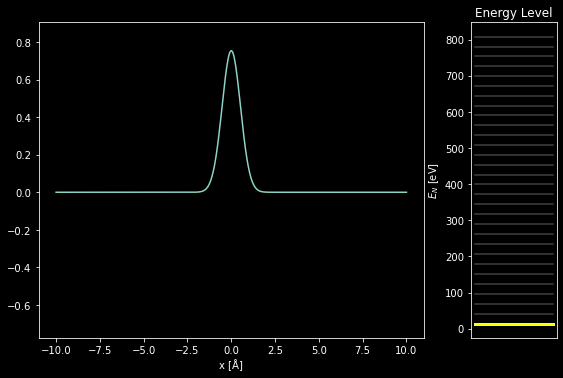

In [3]:
# Harmonic oscillator potential
def harmonic_oscillator(particle):
    k = 100 * eV / Å**2
    return 0.5 * k * particle.x**2

# Define the Hamiltonian
H = Hamiltonian(particles = SingleParticle(), potential = harmonic_oscillator, 
                spatial_ndim = 1, N = 512, extent = 20*Å)

#Diagonalize the Hamiltonian and compute the eigenstates
eigenstates = H.solve(max_states = 30)

# Print out the energies of the eigenstates
print(eigenstates.energies) # the printed energies are expressed in eV

# Visualize the Eigenstates
visualization = init_visualization(eigenstates)
visualization.plot_eigenstate(0)

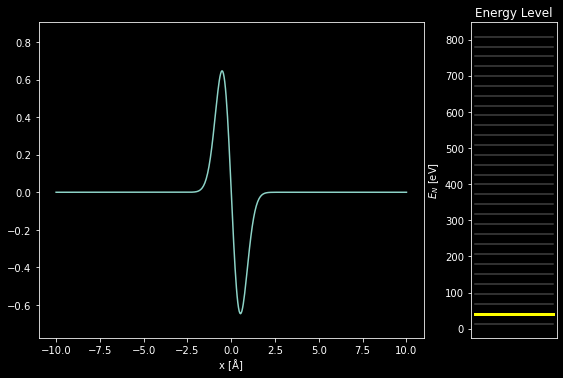

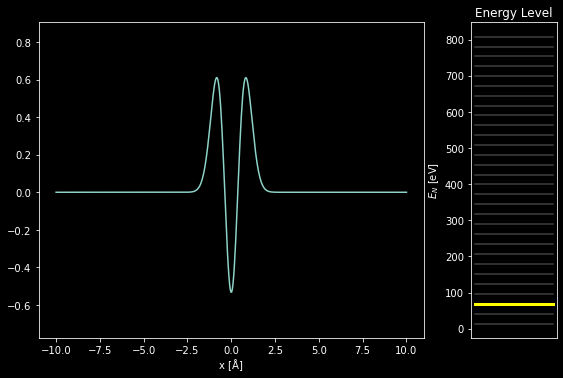

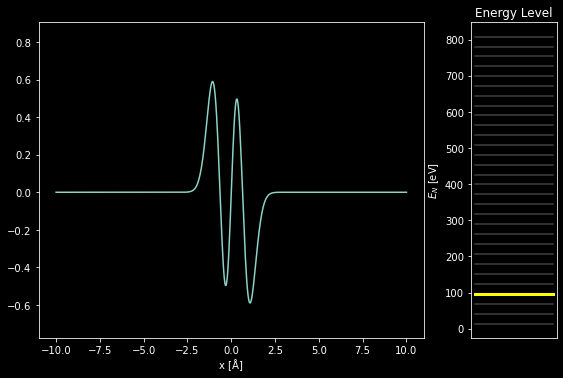

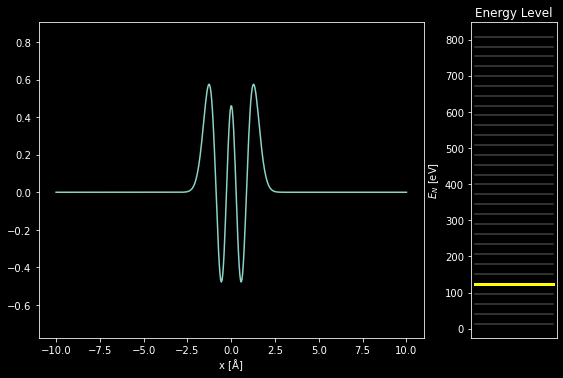

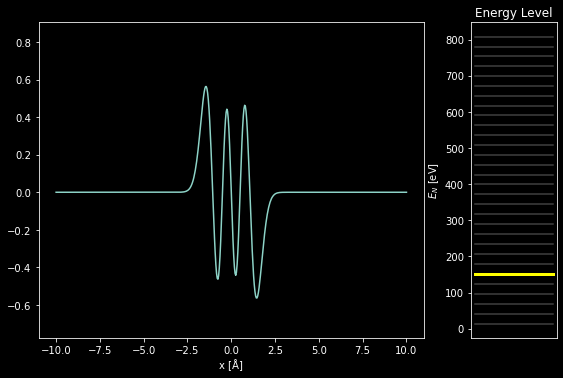

In [4]:
#4.
visualization.plot_eigenstate(1)
visualization.plot_eigenstate(2)
visualization.plot_eigenstate(3)
visualization.plot_eigenstate(4)
visualization.plot_eigenstate(5)

<ol start=5>
    <li>What is on the x-axis of your plots?</li>
    <li>Are your plots showing wave functions $\psi(x)$ or probability functions $\psi^*(x) \psi(x)$? How do you know?</li>
</ol>

### New potential: infinite square well

Below I define the infinite square well potential for $L = 8$ Angstroms and plot the two lowest-energy eigenstates (compare to Figure 6.3 in your textbook).

5. The x-axis of the plots represents the particle position x, measured in Angstroms. This corresponds to the spatial coordinate over which the wave function is defined in the Schrodinger equation.

6. The plots are showing the wave function, not the probability density functions. We know this because the plotted curves contain both positive and negative values, while probability densities must always be positive. 

Computing...
Took 0.00831747055053711
[  0.58926935   2.35704264   5.30321556   9.4276143   14.7299955
  21.21004635  28.8673845   37.70155819  47.71204619  58.89825789
  71.2595333   84.79514311  99.50428872 115.3861023  132.43964681
 150.6639161  170.05783494 190.6202591  212.34997539 235.24570176
 259.30608737 284.52971266 310.91508944 338.46066097 367.16480207
 397.0258192  428.04195057 460.21136622 493.53216816 528.00239048]


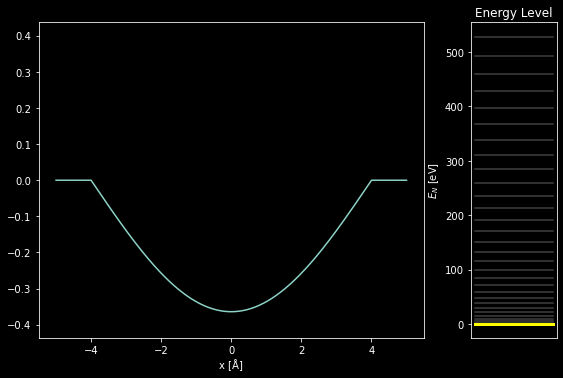

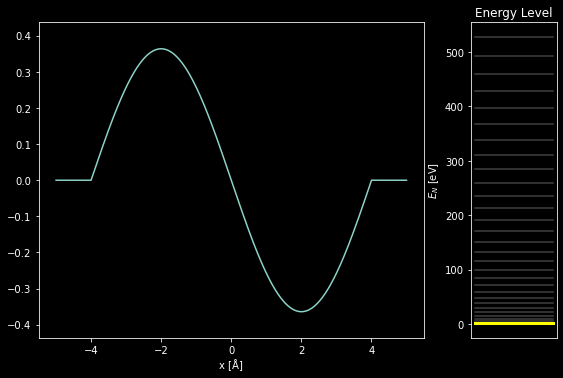

In [5]:
# 8 angstrom-wide infinite square well
def infinite_square_well(particle):
    potential = np.zeros_like(particle.x)
    out_of_bounds = np.abs(particle.x) > 4*Å
    potential[out_of_bounds] = np.inf
    return potential

# Define the Hamiltonian of the infinite square well
H_sw = Hamiltonian(particles = SingleParticle(), potential = infinite_square_well, 
                   spatial_ndim = 1, N = 512, extent = 10*Å)

# Diagonalize the Hamiltonian and compute the eigenstates
eigenstates_sw = H_sw.solve(max_states = 30)

print(eigenstates_sw.energies)

# Visualize the infinite square well eigenstates
visualization_sw = init_visualization(eigenstates_sw)
visualization_sw.plot_eigenstate(0)
visualization_sw.plot_eigenstate(1)

<ol start=7>
    <li>Plot any three infinite square well eigenstates of your choice.</li>
    <li>What property do the infinite square well eigenstates have that's different than the SHO eigenstates? (Hint: think about the properties of valid wave functions we discussed in class)</li>
    <li>What is the relationship between the number of extrema (maxima plus minima) in each eigenstate plot and the quantum number of the eigenstate?</li>
</ol>

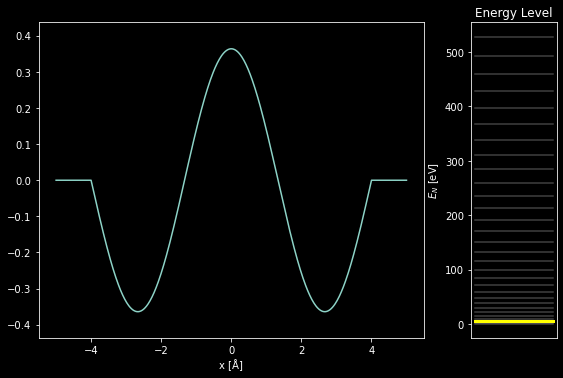

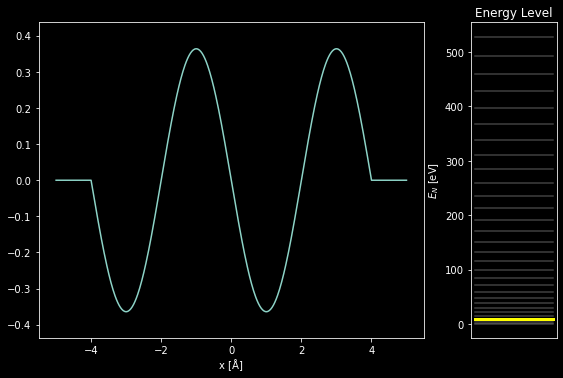

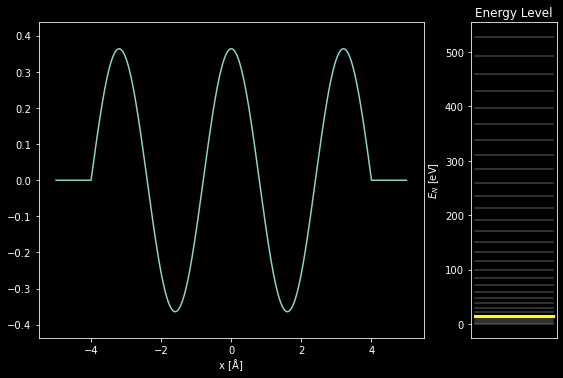

In [7]:
visualization_sw.plot_eigenstate(2)
visualization_sw.plot_eigenstate(3)
visualization_sw.plot_eigenstate(4)

8. The infinite square well eigenstates are different from the simple harmonic oscillator eigenstates because the wave functions go exactly to zero at the walls of the well. This is required becuase the potential outside the well is infinite, so the probability of finding the particle outside the well must be zero. In contrast, SHO wave functions extend infinitely and only approach zero gradually as x becomes very large.

9. There is also a relationship between the number of extrema and the quantum number n. As the quantum number increases, the wave function oscillates more and gains additional maxima and minima. Higher-energy eigenstates therefore have more extrema and more nodes than lower-energy eigenstates. 

### Now it's your turn to define a potential

<ol start=10>
    <li>Write a function that defines a <em>finite square-well</em> potential (textbook section 5.4). You can choose the width of the well in Angstroms and the potential at the walls in eV. Calculate the finite square-well Hamiltonian and plot any five eigenstates you choose.</li>
    <li>Based on your plots, do you think a particle can get out of the finite square-well potential no matter its quantum number $n$?</li>
</ol>

Computing...
Took 0.004091739654541016
[ 0.37456442  1.49824362  3.37099546  5.99274972  9.36340807 13.48284409
 18.3509033  23.96740314 30.33213296 37.44485407]


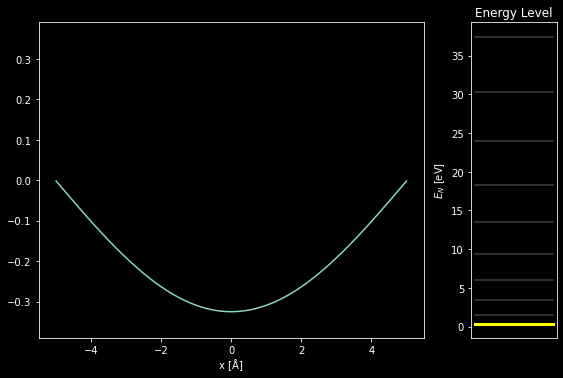

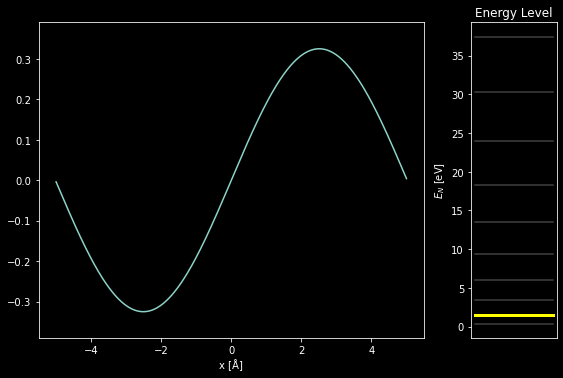

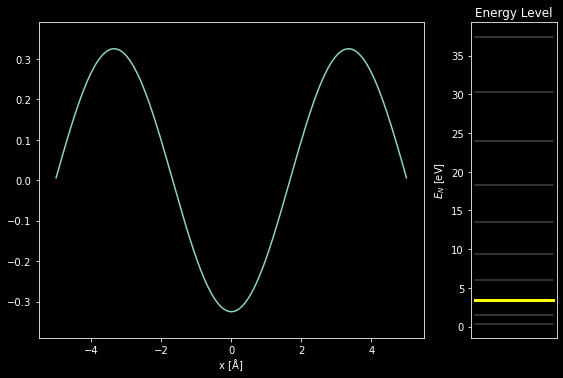

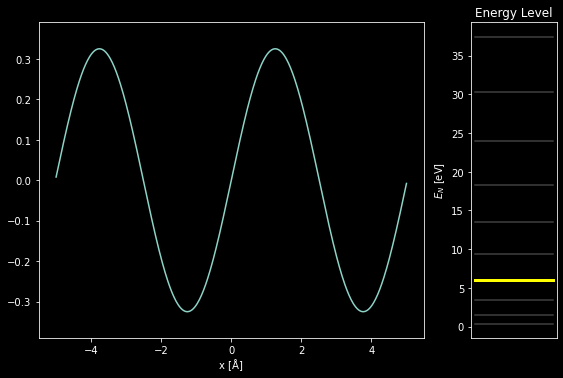

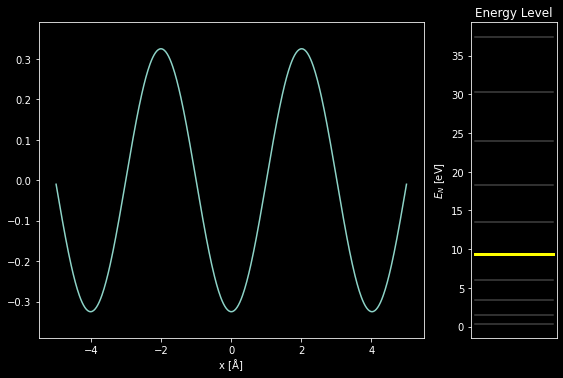

In [8]:
def finite_square_well(particle):
    V0 = 30 * eV
    L= 5 * Å
    potential = np.zeros_like(particle.x)
    out_of_bounds = np.abs(particle.x) > L
    potential[out_of_bounds] = V0
    return potential

H_finite = Hamiltonian(particles = SingleParticle(), potential = finite_square_well, 
                   spatial_ndim = 1, N = 512, extent = 10*Å)

eigenstates = H_finite.solve(max_states = 10)

print(eigenstates.energies)

visualization = init_visualization(eigenstates)
visualization.plot_eigenstate(0)
visualization.plot_eigenstate(1)
visualization.plot_eigenstate(2)
visualization.plot_eigenstate(3)
visualization.plot_eigenstate(4)

11. Yes, a particle in a finite square well is not completely confined for all quantum numbers. Even in bound states, the wave function extends into the barriers, giving a nonzero probability of finding the particle outside the well due to quantum tunneling. For sufficiently high energies, the particle can even become unbound and effectively escape the well.